In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_path = "sample/best-shot-kabukicho.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise Exception("Error membuka video")

# ambil FPS
fps = cap.get(cv2.CAP_PROP_FPS)

# parameter
frame_skip = 5
rows, cols = 5, 5

# ROI (SUDAH DISESUAIKAN DENGAN RESIZE 640x360)
x1, y1 = 0, 130
x2, y2 = 635, 355

print(f"FPS: {fps}")

FPS: 60.0


(np.float64(-0.5), np.float64(639.5), np.float64(359.5), np.float64(-0.5))

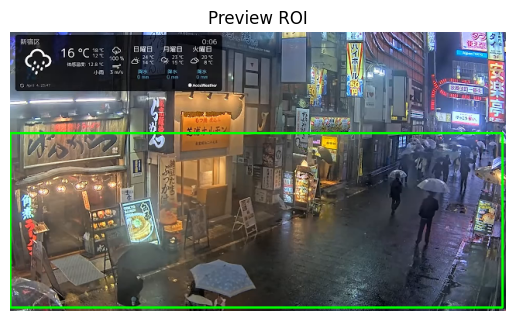

In [56]:
ret, frame = cap.read()

frame = cv2.resize(frame, (640, 360))

# gambar kotak ROI
preview = frame.copy()
cv2.rectangle(preview, (x1, y1), (x2, y2), (0,255,0), 2)

# tampilkan pakai matplotlib (biar di notebook)
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title("Preview ROI")
plt.axis("off")

In [57]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

prev_gray = None
frame_count = 0

total_grid = np.zeros((rows, cols))
frame_used = 0
activity_over_time = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    if frame_count % frame_skip != 0:
        continue

    frame = cv2.resize(frame, (640, 360))
    roi = frame[y1:y2, x1:x2]

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    if prev_gray is None:
        prev_gray = gray
        continue

    diff = cv2.absdiff(prev_gray, gray)
    _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)

    prev_gray = gray

    h, w = thresh.shape
    cell_h = h // rows
    cell_w = w // cols

    grid = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            cell = thresh[
                i*cell_h:(i+1)*cell_h,
                j*cell_w:(j+1)*cell_w
            ]

            activity = np.sum(cell) / 255
            grid[i][j] = activity

    total_grid += grid
    frame_used += 1

    frame_activity = np.sum(grid)
    activity_over_time.append(frame_activity)

cap.release()

print("Processing selesai")

Processing selesai


In [58]:
# normalisasi
normalized_grid = total_grid / frame_used
real_total = np.sum(activity_over_time)

# waktu
time_per_point = frame_skip / fps
time_series = [i * time_per_point for i in range(len(activity_over_time))]

# statistik
max_val = float(np.max(activity_over_time))
min_val = float(np.min(activity_over_time))
avg_val = float(np.mean(activity_over_time))
peak_index = int(np.argmax(activity_over_time))
peak_time = peak_index * time_per_point
grid_avg_sum = np.sum(normalized_grid)

duration = len(activity_over_time) * time_per_point

print("=== STATISTIK ===")
print("Total (real):", real_total)
print("Max:", max_val)
print("Min:", min_val)
print("Average:", avg_val)
print("Grid-based avg total:", grid_avg_sum)
print("Peak time:", peak_time)

=== STATISTIK ===
Total (real): 6512687.0
Max: 16029.0
Min: 3.0
Average: 4519.560721721027
Grid-based avg total: 4519.560721721027
Peak time: 44.58333333333333


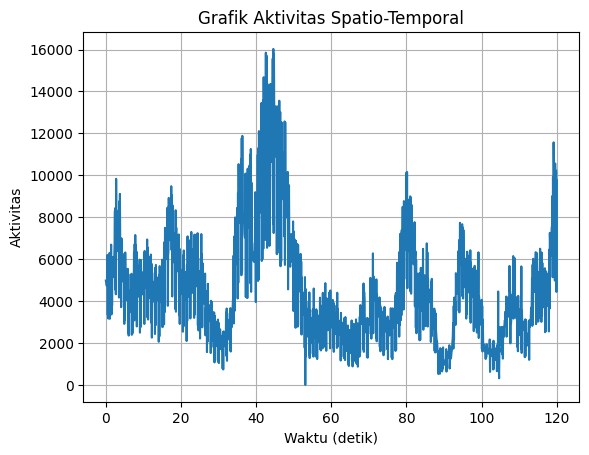

In [59]:
plt.figure()
plt.plot(time_series, activity_over_time)
plt.xlabel("Waktu (detik)")
plt.ylabel("Aktivitas")
plt.title("Grafik Aktivitas Spatio-Temporal")
plt.grid()

plt.show()

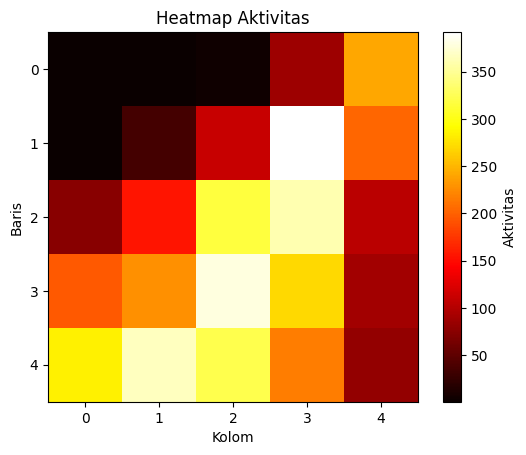

In [60]:
plt.figure()
plt.imshow(normalized_grid, cmap='hot')
plt.colorbar(label="Aktivitas")
plt.title("Heatmap Aktivitas")
plt.xlabel("Kolom")
plt.ylabel("Baris")

plt.show()

In [61]:
result = {
    "summary": {
        "duration": float(duration),
        "total_activity": float(real_total),
        "average": avg_val,
        "max": max_val,
        "min": min_val,
        "peak_time": float(peak_time)
    },
    "graph": {
        "time": time_series,
        "activity": [float(x) for x in activity_over_time]
    },
    "heatmap": normalized_grid.tolist()
}

import json
print(json.dumps(result, indent=2))

{
  "summary": {
    "duration": 120.08333333333333,
    "total_activity": 6512687.0,
    "average": 4519.560721721027,
    "max": 16029.0,
    "min": 3.0,
    "peak_time": 44.58333333333333
  },
  "graph": {
    "time": [
      0.0,
      0.08333333333333333,
      0.16666666666666666,
      0.25,
      0.3333333333333333,
      0.41666666666666663,
      0.5,
      0.5833333333333333,
      0.6666666666666666,
      0.75,
      0.8333333333333333,
      0.9166666666666666,
      1.0,
      1.0833333333333333,
      1.1666666666666665,
      1.25,
      1.3333333333333333,
      1.4166666666666665,
      1.5,
      1.5833333333333333,
      1.6666666666666665,
      1.75,
      1.8333333333333333,
      1.9166666666666665,
      2.0,
      2.083333333333333,
      2.1666666666666665,
      2.25,
      2.333333333333333,
      2.4166666666666665,
      2.5,
      2.583333333333333,
      2.6666666666666665,
      2.75,
      2.833333333333333,
      2.9166666666666665,
      3.0,
     